# Using Masimo's Algorithm on Normalized Derivative Time Series
In this notebook, we test out Masimo's algorithm on normalized derivaties calculated off of different TFO PPG probe data. We try this out across some time window to determine if the R predicted from the algorithm does track saturation. (Or if there is atleast some sort of a trend) 

## Preprocessing Steps
1. The normalized derivative produces some very wild outlier points. Clipping the outputs at 5 and 95 percentile
2. Filter around 1.5Hz 
3. Moving avg. 

## Preliminary Results
Does not work. I do not see the usual streak along time at/ around a certain R. The R peaks are spreaded all throughout!

In [1]:
import numpy as np
import matlab.engine
import pandas as pd
import matplotlib.pyplot as plt
# from TFO_dataset import SheepData
from tfo_masimo.preprocessing.custom_preprocessing import normalized_derivative
from tfo_masimo.preprocessing.adaptive_filters import adaptive_filter_lms, adaptive_filter_rls
from tfo_masimo.visualization.spectrograms import generate_spectrogram, get_manipulated_stft_inverse_kaiser
from scipy.signal import get_window
from scipy.stats.mstats import winsorize
from scipy.signal import savgol_filter, get_window
from tqdm import tqdm

np.random.seed(0)


c:\Users\Sebastian Najbjerg\AppData\Local\Programs\Python\Python313\Lib\site-packages\matlab\__init__.py:158: UserWarning: Python versions 3.9, 3.10, 3.11, and 3.12 are supported, but your version of Python is 3_13
  warnings.warn('Python versions 3.9, 3.10, 3.11, and 3.12 are supported, but your version of Python is %s' % _version)
c:\Users\Sebastian Najbjerg\AppData\Local\Programs\Python\Python313\Lib\site-packages\matlab\engine\__init__.py:43: UserWarning: MATLAB Engine for Python supports Python version 3.9, 3.10, 3.11, and 3.12, but your version of Python is 3_13
  warnings.warn('MATLAB Engine for Python supports Python version'


In [2]:
# Load CSV data
df = pd.read_csv("C:/Users/Sebastian Najbjerg/Desktop/LEPSUCD/log12.csv")
ppg = df[['IR', 'RED', 'RatioAverage', 'SpO2']].to_numpy()
FS = 246

min_len = len(ppg)
ppg = ppg[:min_len, :]
ppg_timeline = np.arange(0, stop=min_len / FS, step=1/FS)

In [3]:
%matplotlib widget

'\nplt.figure()\nplt.plot(ppg[:,2])\nplt.figure()\nplt.plot(ppg[:,3])\n'

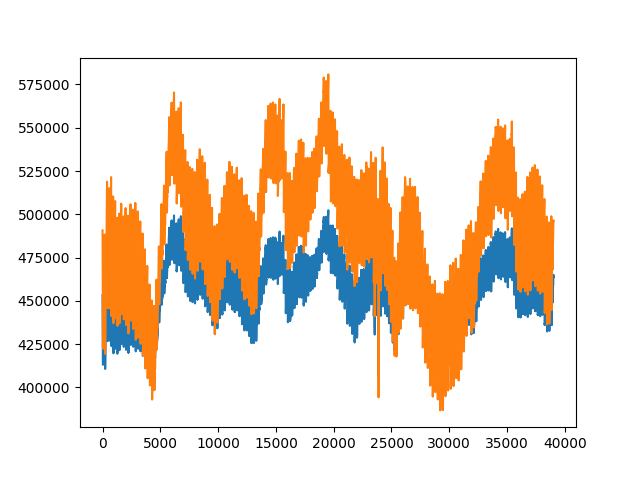

In [4]:
DERIVATIVE_PADDING_SAMPLE_COUNT = 100
_, rd = normalized_derivative(ppg[:, 1])  # RED
_, ir = normalized_derivative(ppg[:, 0])  # IR
rd = rd[DERIVATIVE_PADDING_SAMPLE_COUNT:-DERIVATIVE_PADDING_SAMPLE_COUNT]
ir = ir[DERIVATIVE_PADDING_SAMPLE_COUNT:-DERIVATIVE_PADDING_SAMPLE_COUNT]
plt.figure()
plt.plot(ppg[:,1])
plt.plot(ppg[:,0])

# Plot the ratio and Spo2 over time
'''
plt.figure()
plt.plot(ppg[:,2])
plt.figure()
plt.plot(ppg[:,3])
'''



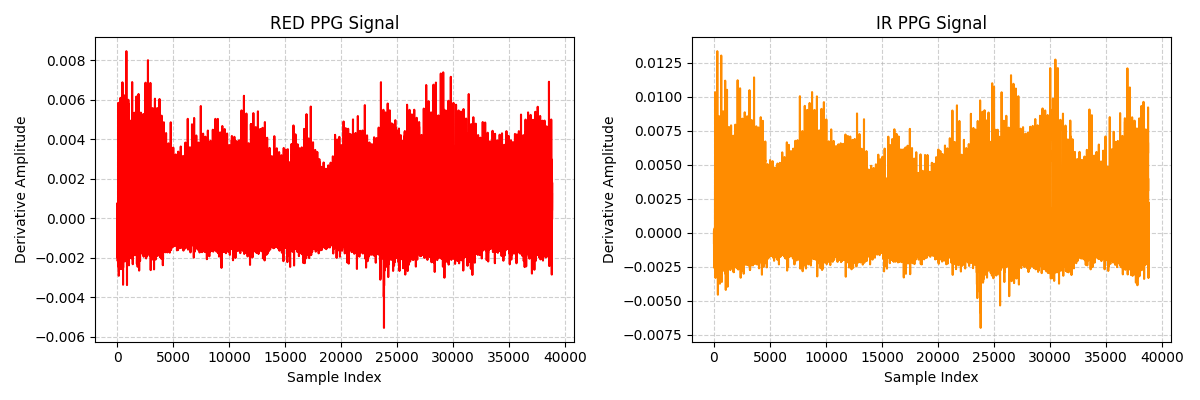

In [5]:
# Plotting the Normalized Derivatives of the Red and IR PPG Components
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Plot RED signal
ax1.plot(rd, color='red', linewidth=1.5)
ax1.set_title('RED PPG Signal')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Derivative Amplitude')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot IR signal
ax2.plot(ir, color='darkorange', linewidth=1.5)
ax2.set_title('IR PPG Signal')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Derivative Amplitude')
ax2.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


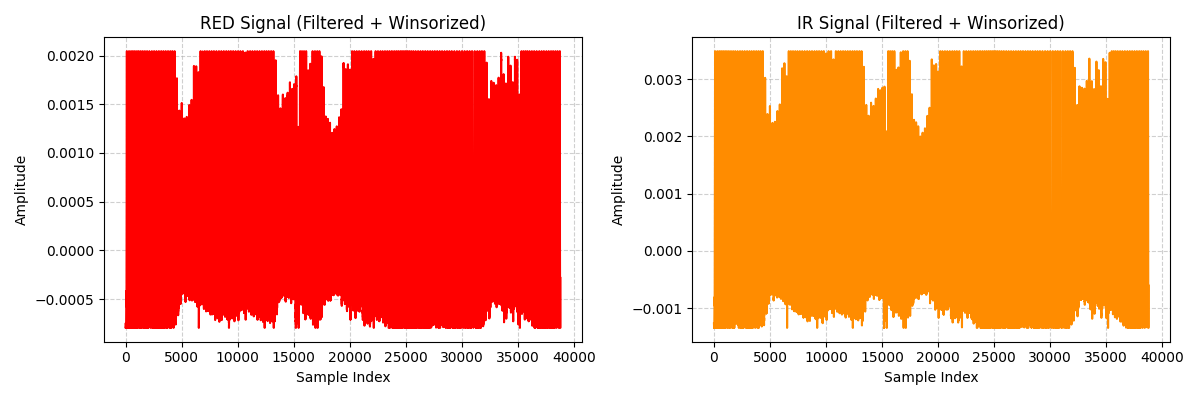

In [6]:
# MA
MA_FILTER_LENGTH = 30
ir = np.convolve(ir, np.ones((MA_FILTER_LENGTH,)), mode='valid') / MA_FILTER_LENGTH
rd = np.convolve(rd, np.ones((MA_FILTER_LENGTH,)), mode='valid') / MA_FILTER_LENGTH
# Outlier
ir = winsorize(ir, [0.05, 0.05 ])
rd = winsorize(rd, [0.05, 0.05 ])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Plot RD
ax1.plot(rd, color='red', linewidth=1.5)
ax1.set_title('RED Signal (Filtered + Winsorized)')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Amplitude')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot IR
ax2.plot(ir, color='darkorange', linewidth=1.5)
ax2.set_title('IR Signal (Filtered + Winsorized)')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Amplitude')
ax2.grid(True, linestyle='--', alpha=0.6)

# Improve layout
plt.tight_layout()
plt.show()

In [7]:
# Spectrum Filtering
ir = get_manipulated_stft_inverse_kaiser(ir, [1.5], window_length=30, fhr_bins_to_keep= 10, fs=FS)
rd = get_manipulated_stft_inverse_kaiser(rd, [1.5], window_length=30, fhr_bins_to_keep= 10, fs=FS)

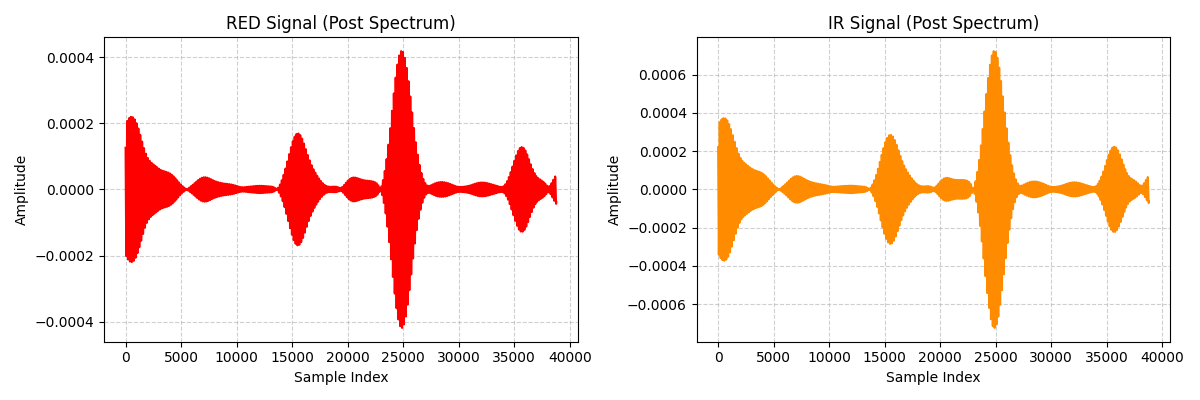

In [8]:
#Plot IR and RD after spectrum filtering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Plot RD
ax1.plot(rd, color='red', linewidth=1.5)
ax1.set_title('RED Signal (Post Spectrum)')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Amplitude')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot IR
ax2.plot(ir, color='darkorange', linewidth=1.5)
ax2.set_title('IR Signal (Post Spectrum)')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Amplitude')
ax2.grid(True, linestyle='--', alpha=0.6)

# Improve layout
plt.tight_layout()
plt.show()

## Signal Spectrum
Masmim'o algorithm is essentially based on filtering the signal based on their spectrums. If the spectrum itself is not clean, I do not expect the rest of the things to work out

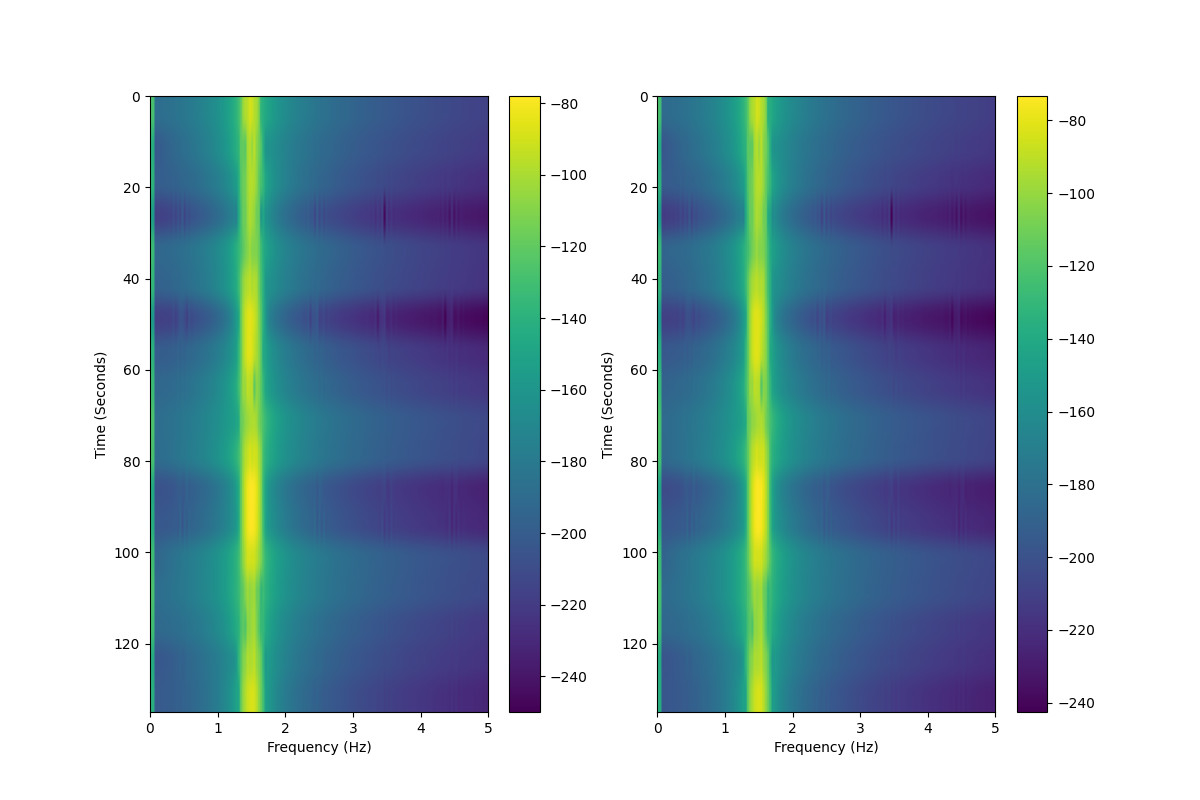

In [9]:

rd_spectrogram = generate_spectrogram(rd, FS, window_length=30, overlap_percent=3/4)
ir_spectrogram = generate_spectrogram(ir, FS, window_length=30, overlap_percent=3/4)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
rd_spectrogram.plot([0, 5])
plt.colorbar()

plt.subplot(1, 2, 2)
ir_spectrogram.plot([0, 5])
plt.colorbar()
plt.show()

## Masimo Alg.

In [10]:
# Filter Params
n = 100
forgetting_factor = 1 - 1 / (8 * FS)

# Warning : This part takes a while
peak_r = []
energy_map = []
r_time_axis = []
window_length = 35 * FS  
overlap_percnt = 0.3

r_values_fetal = np.arange(0.3, 1, step=0.025)
# r_values_fetal = np.arange(0.3, 1.0, step=0.05)

plot_window_indices = [2, 5, 7]  # Windows Graphed

for i in range(120):
    starting_sample = int(i * window_length * overlap_percnt)
    ending_sample = int(starting_sample + window_length)
    if ending_sample > len(rd):
        break

    r_time_axis.append((starting_sample + ending_sample) // 2 * 1 / FS)

    filtered_rd = rd[starting_sample: ending_sample]
    filtered_ir = ir[starting_sample: ending_sample]

    calculated_energies_fetal = []
    residuals_for_plot = []
    rs_for_plot = []

    for r in r_values_fetal:

        rs = r * filtered_ir - filtered_rd
        
        _, residual, __ = adaptive_filter_lms(rs, filtered_rd, filter_length=n, filter_lambda=forgetting_factor)

        residual = residual[20 * FS:]  # Drop unstable part
        residual = residual * get_window('hann', len(residual))
        energy = np.mean(residual * residual) 
        calculated_energies_fetal.append(energy)

        if i in plot_window_indices:
            residuals_for_plot.append(residual)

    max_energy = max(calculated_energies_fetal)
    max_energy_index = calculated_energies_fetal.index(max_energy)
    peak_r.append(r_values_fetal[max_energy_index])
    energy_map.append(np.array(calculated_energies_fetal) / max_energy)  # Normalize per window
    '''
    if i in plot_window_indices:
        # Plot residual waveforms for min, middle, and max r
        r_plot_indices = [0, len(r_values_fetal) // 2, -1]
        plt.figure(figsize=(10, 4))
        for idx in r_plot_indices:
            label = f"r = {r_values_fetal[idx]:.2f}"
            plt.plot(residuals_for_plot[idx], label=label)
        plt.title(f"Residual Waveforms (Window {i})")
        plt.xlabel("Sample")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        #Plotting the inputs for each of the winows to compare
        plt.figure(figsize=(10, 4))
        plt.plot(filtered_ir, label='IR (Raw)', color='darkred')
        plt.plot(filtered_rd, label='RED (Raw)', color='navy')
        plt.title(f"Input IR and RED Signals (Window {i})")
        plt.xlabel("Sample")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        '''
        


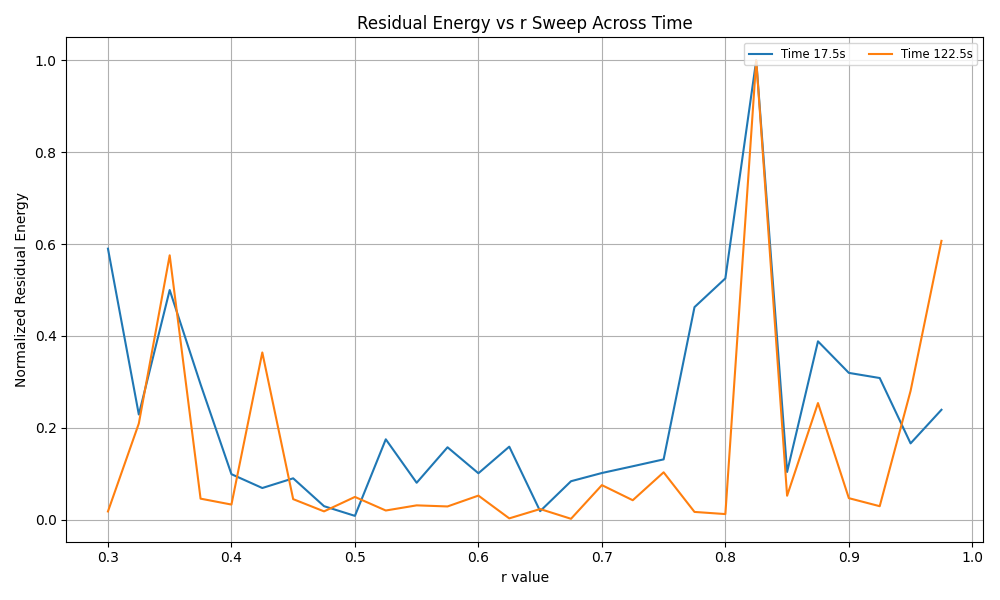

In [11]:
# Plotting individual r_values_fetal to try to isolate the reason for variance
plt.figure(figsize=(10, 6))
for sweep_idx in range(0, len(energy_map), 10):  # Plot every 5th window
    plt.plot(r_values_fetal, energy_map[sweep_idx], label=f'Time {r_time_axis[sweep_idx]:.1f}s')

plt.xlabel('r value')
plt.ylabel('Normalized Residual Energy')
plt.title('Residual Energy vs r Sweep Across Time')
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

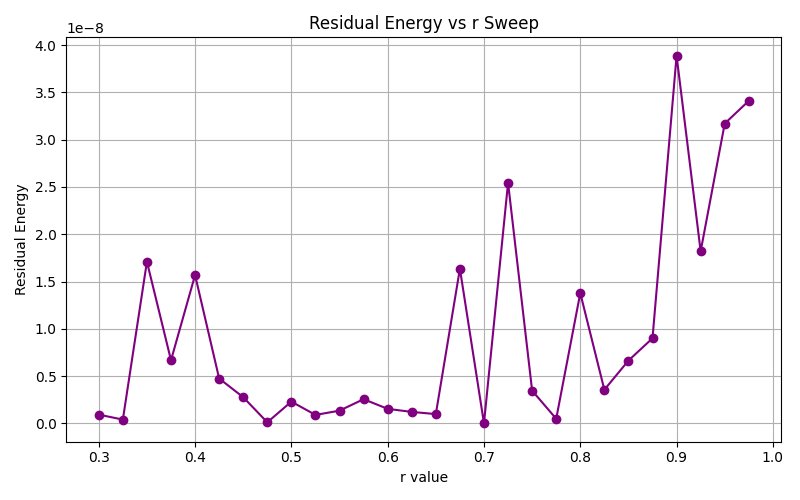

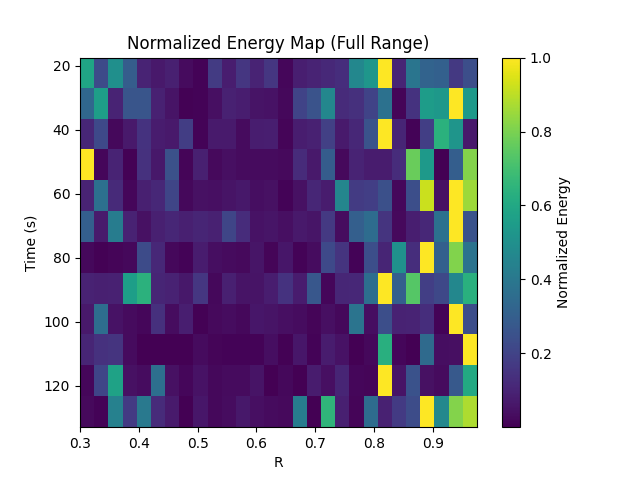

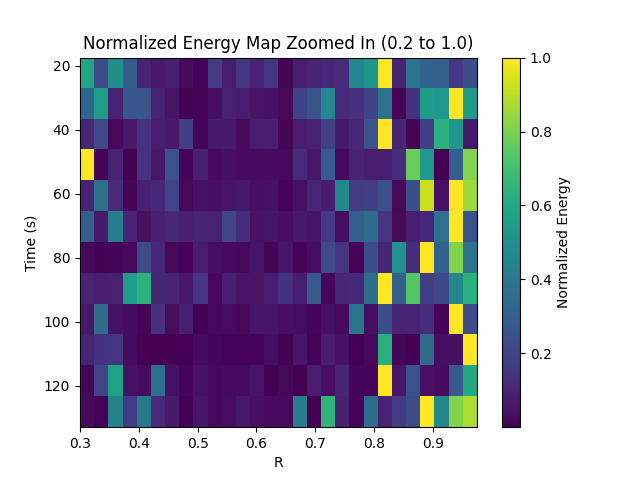

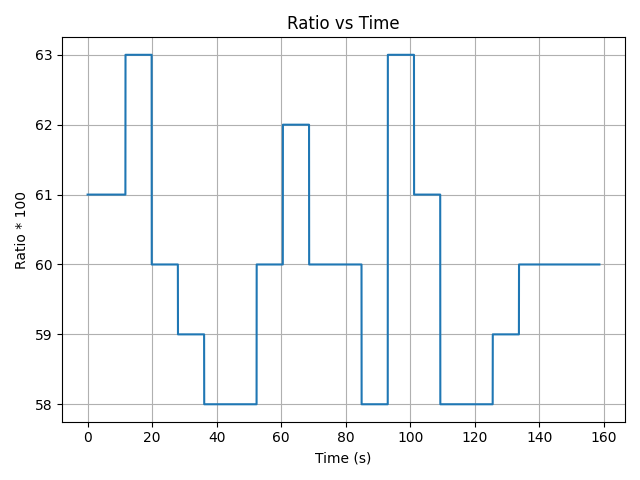

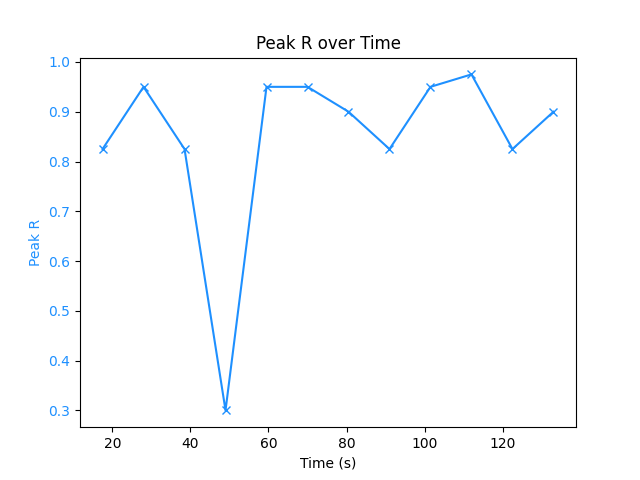

In [12]:

# Normalize energy_map
energy_map = np.array(energy_map)
energy_map_norm = energy_map / np.max(energy_map)

# --- Plot full energy map ---
plt.figure()
plt.imshow(energy_map_norm,
           extent=[r_values_fetal[0], r_values_fetal[-1], r_time_axis[-1], r_time_axis[0]],
           interpolation=None, aspect="auto")
plt.xlabel('R')
plt.ylabel('Time (s)')
plt.colorbar(label='Normalized Energy')
plt.title("Normalized Energy Map (Full Range)")

# --- Plot zoomed-in energy map for R
r_min, r_max = 0.2, 1.0

# Find indices corresponding to zoom range
zoom_indices = np.where((r_values_fetal >= r_min) & (r_values_fetal <= r_max))[0]

plt.figure()
plt.imshow(energy_map_norm[:, zoom_indices],
           extent=[r_values_fetal[zoom_indices[0]], r_values_fetal[zoom_indices[-1]], r_time_axis[-1], r_time_axis[0]],
           interpolation=None, aspect="auto")
plt.xlabel('R')
plt.ylabel('Time (s)')
plt.colorbar(label='Normalized Energy')
plt.title(f"Normalized Energy Map Zoomed In ({r_min} to {r_max})")

# Plot the calculated ratio values
plt.figure()
plt.plot(ppg_timeline, ppg[:, 3]) 
plt.xlabel("Time (s)")
plt.ylabel("Ratio * 100")
plt.title("Ratio vs Time")
plt.grid(True)
plt.tight_layout()

# Plot Peak R over time
fig, ax1 = plt.subplots()
ax1.plot(r_time_axis, peak_r, 'x-', color='dodgerblue')
ax1.set_ylabel('Peak R', color='dodgerblue')
ax1.set_xlabel('Time (s)')
ax1.tick_params(axis='y', labelcolor='dodgerblue')
ax1.set_title("Peak R over Time")

# Plot Residual Energy vs r Sweep
plt.figure(figsize=(8, 5))
plt.plot(r_values_fetal, calculated_energies_fetal, marker='o', color='purple')
plt.xlabel("r value")
plt.ylabel("Residual Energy")
plt.title("Residual Energy vs r Sweep")
plt.grid(True)
plt.tight_layout()

plt.show()


Pearson correlation between Peak R and Ratio (/100): 0.383
Max cross-correlation: 0.544 at lag -23 samples (~-5.324 seconds)


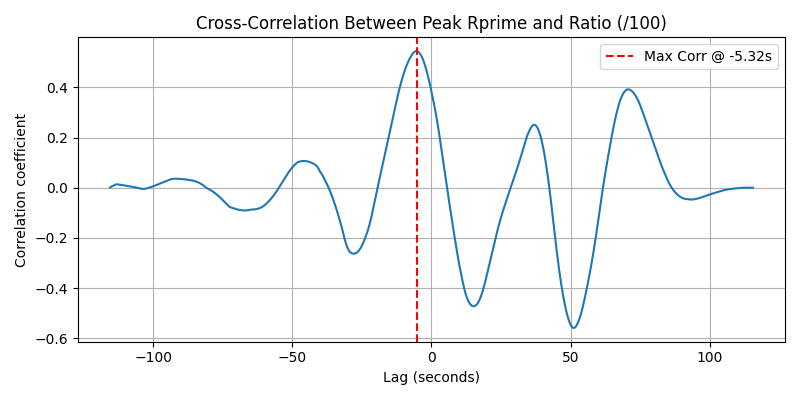

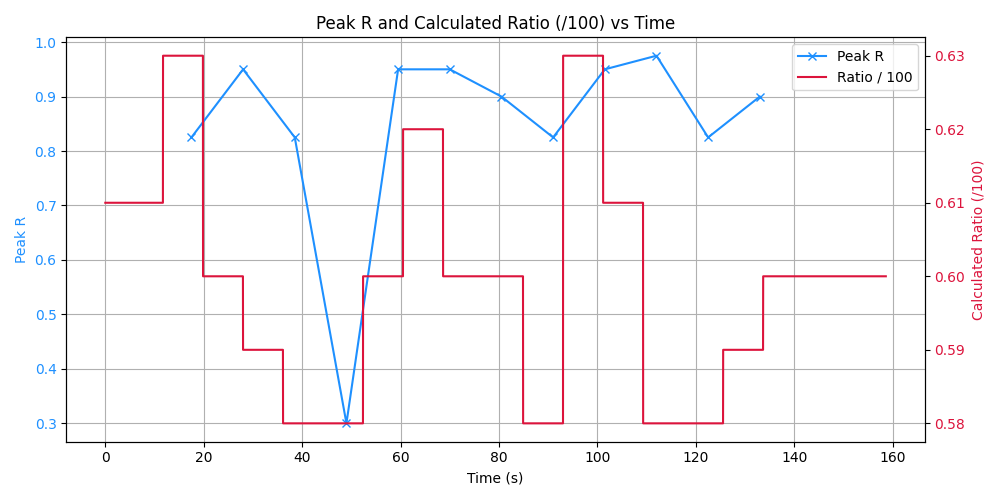

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from scipy.signal import correlate

# --- Interpolate both signals to a common time base ---
common_time = np.linspace(max(min(r_time_axis), min(ppg_timeline)),
                          min(max(r_time_axis), max(ppg_timeline)),
                          num=500)

# Interpolate both arrays
interp_peak_r = interp1d(r_time_axis, peak_r, kind='linear', fill_value='extrapolate')
interp_ratio = interp1d(ppg_timeline, ppg[:, 3] / 100, kind='linear', fill_value='extrapolate')

peak_r_interp_values = interp_peak_r(common_time)
ratio_interp_values = interp_ratio(common_time)

# --- Compute Pearson correlation ---
correlation, _ = pearsonr(peak_r_interp_values, ratio_interp_values)
print(f"Pearson correlation between Peak R and Ratio (/100): {correlation:.3f}")

# --- Cross-correlation computation ---
x = peak_r_interp_values - np.mean(peak_r_interp_values)
y = ratio_interp_values - np.mean(ratio_interp_values)

lags = np.arange(-len(x) + 1, len(x))
cross_corr = correlate(y, x, mode='full') / (np.std(x) * np.std(y) * len(x))

# Find the lag with maximum correlation
max_corr_idx = np.argmax(cross_corr)
max_corr = cross_corr[max_corr_idx]
best_lag = lags[max_corr_idx]

# Convert lag from samples to seconds (optional)
sample_interval = common_time[1] - common_time[0]
best_lag_seconds = best_lag * sample_interval

print(f"Max cross-correlation: {max_corr:.3f} at lag {best_lag} samples (~{best_lag_seconds:.3f} seconds)")

# --- Plot Cross-Correlation ---
plt.figure(figsize=(8, 4))
plt.plot(lags * sample_interval, cross_corr)
plt.title('Cross-Correlation Between Peak Rprime and Ratio (/100)')
plt.xlabel('Lag (seconds)')
plt.ylabel('Correlation coefficient')
plt.axvline(best_lag_seconds, color='red', linestyle='--', label=f'Max Corr @ {best_lag_seconds:.2f}s')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Peak R
color1 = 'dodgerblue'
ax1.plot(r_time_axis, peak_r, 'x-', color=color1, label='Peak R')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Peak R', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Plot Ratio (/100)
ax2 = ax1.twinx()
color2 = 'crimson'
ax2.plot(ppg_timeline, ppg[:, 3] / 100, '-', color=color2, label='Ratio / 100')
ax2.set_ylabel('Calculated Ratio (/100)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Title and grid
plt.title("Peak R and Calculated Ratio (/100) vs Time")
ax1.grid(True)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


In [14]:


'''
# Start MATLAB Engine
eng = matlab.engine.start_matlab()
eng.eval("d = dsp.LMSFilter('Length', 32, 'StepSize', 0.01);", nargout=0)  # LMS filter initialization

# Filter Params
n = 100
forgetting_factor = 1 - 1 / (40 * FS)

peak_r = []
energy_map = []
r_time_axis = []
window_length = 35 * FS  
overlap_percnt = 0.3

r_values_fetal = np.arange(0.2, 2.0, step=0.05)
plot_window_indices = [2, 5, 7]  # Windows Graphed

for i in range(120):
    starting_sample = int(i * window_length * overlap_percnt)
    ending_sample = int(starting_sample + window_length)
    if ending_sample > len(rd):
        break

    r_time_axis.append((starting_sample + ending_sample) // 2 * 1 / FS)

    filtered_rd = rd[starting_sample: ending_sample]
    filtered_ir = ir[starting_sample: ending_sample]

    # Normalize signals for stable LMS ANC convergence
    filtered_rd_norm = (filtered_rd - np.mean(filtered_rd)) / np.std(filtered_rd)
    filtered_ir_norm = (filtered_ir - np.mean(filtered_ir)) / np.std(filtered_ir)

    calculated_energies_fetal = []
    residuals_for_plot = []

    for r in r_values_fetal:
        rs = r * filtered_ir_norm - filtered_rd_norm

        # Send as column vectors
        eng.workspace['rs'] = matlab.double([[val] for val in rs])
        eng.workspace['ref'] = matlab.double([[val] for val in filtered_ir_norm])

        # Perform ANC using dsp.LMSFilter:
        eng.eval("[~, e] = d(ref, rs);", nargout=0)

        # Retrieve residual
        residual = np.array(eng.workspace['e']).flatten()

        # Post-processing consistent with pipeline
        residual = residual[25 * FS:]  # Drop unstable part
        residual = residual * get_window('hann', len(residual))
        energy = np.mean(residual ** 2)
        calculated_energies_fetal.append(energy)

        if i in plot_window_indices:
            residuals_for_plot.append(residual)


    max_energy = max(calculated_energies_fetal)
    max_energy_index = calculated_energies_fetal.index(max_energy)
    peak_r.append(r_values_fetal[max_energy_index])
    energy_map.append(np.array(calculated_energies_fetal))


    if i in plot_window_indices:
        # Plot residual waveforms for min, middle, and max r
        r_plot_indices = [0, len(r_values_fetal) // 2, -1]
        plt.figure(figsize=(10, 4))
        for idx in r_plot_indices:
            label = f"r = {r_values_fetal[idx]:.2f}"
            plt.plot(residuals_for_plot[idx], label=label)
        plt.title(f"Residual Waveforms after MATLAB ANC (Window {i})")
        plt.xlabel("Sample")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

eng.quit()
'''


'\n# Start MATLAB Engine\neng = matlab.engine.start_matlab()\neng.eval("d = dsp.LMSFilter(\'Length\', 32, \'StepSize\', 0.01);", nargout=0)  # LMS filter initialization\n\n# Filter Params\nn = 100\nforgetting_factor = 1 - 1 / (40 * FS)\n\npeak_r = []\nenergy_map = []\nr_time_axis = []\nwindow_length = 35 * FS  \noverlap_percnt = 0.3\n\nr_values_fetal = np.arange(0.2, 2.0, step=0.05)\nplot_window_indices = [2, 5, 7]  # Windows Graphed\n\nfor i in range(120):\n    starting_sample = int(i * window_length * overlap_percnt)\n    ending_sample = int(starting_sample + window_length)\n    if ending_sample > len(rd):\n        break\n\n    r_time_axis.append((starting_sample + ending_sample) // 2 * 1 / FS)\n\n    filtered_rd = rd[starting_sample: ending_sample]\n    filtered_ir = ir[starting_sample: ending_sample]\n\n    # Normalize signals for stable LMS ANC convergence\n    filtered_rd_norm = (filtered_rd - np.mean(filtered_rd)) / np.std(filtered_rd)\n    filtered_ir_norm = (filtered_ir - np.m

In [15]:
#Plot the results from matlab
'''
# Plot energy map
plt.figure()
energy_map = np.array(energy_map)
energy_map = energy_map / np.max(energy_map)
plt.imshow(energy_map, extent=[r_values_fetal[0], r_values_fetal[-1], r_time_axis[-1], r_time_axis[0]],
           interpolation=None, aspect="auto")
plt.xlabel('R')
plt.ylabel('Time (s)')
plt.colorbar(label='Normalized Energy')

# Plot Peak R over time (no saturation)
fig, ax1 = plt.subplots()
ax1.plot(r_time_axis, peak_r, 'x-', color='dodgerblue')
ax1.set_ylabel('Peak R', color='dodgerblue')
ax1.set_xlabel('Time (s)')
ax1.tick_params(axis='y', labelcolor='dodgerblue')
ax1.set_title("Peak R over Time")

#Plot first sweep
plt.figure(figsize=(8, 5))
plt.plot(r_values_fetal, calculated_energies_fetal, marker='o', color='purple')
plt.xlabel("r value")
plt.ylabel("Residual Energy")
plt.title("Residual Energy vs r Sweep")
plt.grid(True)
plt.tight_layout()
plt.show()
'''

'\n# Plot energy map\nplt.figure()\nenergy_map = np.array(energy_map)\nenergy_map = energy_map / np.max(energy_map)\nplt.imshow(energy_map, extent=[r_values_fetal[0], r_values_fetal[-1], r_time_axis[-1], r_time_axis[0]],\n           interpolation=None, aspect="auto")\nplt.xlabel(\'R\')\nplt.ylabel(\'Time (s)\')\nplt.colorbar(label=\'Normalized Energy\')\n\n# Plot Peak R over time (no saturation)\nfig, ax1 = plt.subplots()\nax1.plot(r_time_axis, peak_r, \'x-\', color=\'dodgerblue\')\nax1.set_ylabel(\'Peak R\', color=\'dodgerblue\')\nax1.set_xlabel(\'Time (s)\')\nax1.tick_params(axis=\'y\', labelcolor=\'dodgerblue\')\nax1.set_title("Peak R over Time")\n\n#Plot first sweep\nplt.figure(figsize=(8, 5))\nplt.plot(r_values_fetal, calculated_energies_fetal, marker=\'o\', color=\'purple\')\nplt.xlabel("r value")\nplt.ylabel("Residual Energy")\nplt.title("Residual Energy vs r Sweep")\nplt.grid(True)\nplt.tight_layout()\nplt.show()\n'